In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [16]:
df = pd.read_csv('/content/drive/MyDrive/DATASETS/winequality-red.csv')

In [17]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:

X = df.drop([ 'quality'], axis=1)
y = df['quality']

In [19]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X = X_scaled


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1279, 11)
X_test shape: (320, 11)
y_train shape: (1279,)
y_test shape: (320,)


In [21]:

from sklearn.neighbors import KNeighborsClassifier

n_neighbors=5
knn_model = KNeighborsClassifier(n_neighbors=5)


knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [22]:

y_pred = knn_model.predict(X_test)

print("Predictions made successfully.")
print(f"First 5 predictions: {y_pred[:5]}")
print(f"Actual first 5 test labels: {y_test[:5]}")

Predictions made successfully.
First 5 predictions: [5 5 6 6 6]
Actual first 5 test labels: 803     6
124     5
350     6
682     5
1326    6
Name: quality, dtype: int64


In [23]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")


class_report = classification_report(y_test, y_pred)
print("\nClassification Report:")
print(class_report)


conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)


Accuracy: 0.5531

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.33      0.10      0.15        10
           5       0.60      0.68      0.64       130
           6       0.52      0.56      0.54       132
           7       0.52      0.33      0.41        42
           8       0.00      0.00      0.00         5

    accuracy                           0.55       320
   macro avg       0.33      0.28      0.29       320
weighted avg       0.54      0.55      0.54       320


Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 0  1  3  6  0  0]
 [ 0  2 88 40  0  0]
 [ 1  0 47 74 10  0]
 [ 0  0  7 21 14  0]
 [ 0  0  1  1  3  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy for k=1: 0.6188
Accuracy for k=2: 0.5406
Accuracy for k=3: 0.5125
Accuracy for k=4: 0.5375
Accuracy for k=5: 0.5531
Accuracy for k=6: 0.5656
Accuracy for k=7: 0.5531
Accuracy for k=8: 0.5750
Accuracy for k=9: 0.5500
Accuracy for k=10: 0.5781
Accuracy for k=11: 0.5656
Accuracy for k=12: 0.5625
Accuracy for k=13: 0.5781
Accuracy for k=14: 0.5687
Accuracy for k=15: 0.5563
Accuracy for k=16: 0.5563
Accuracy for k=17: 0.5563
Accuracy for k=18: 0.5469
Accuracy for k=19: 0.5125
Accuracy for k=20: 0.5281


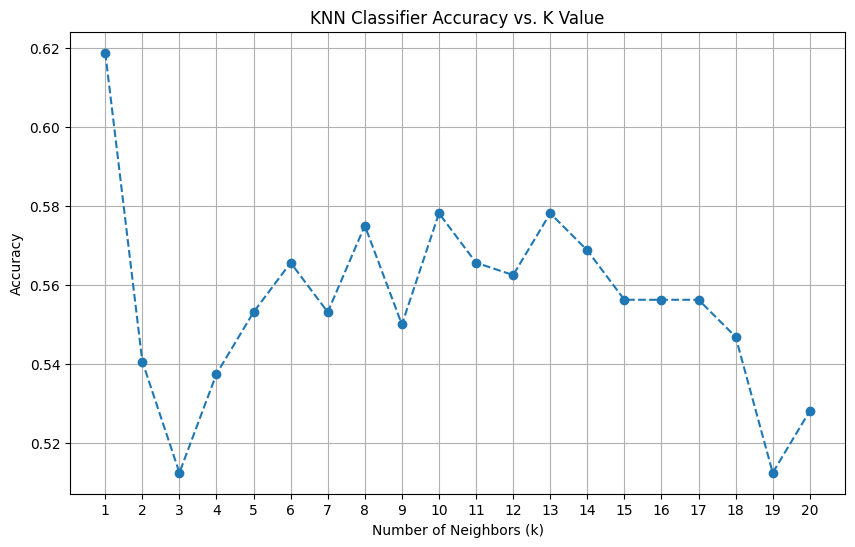


Best k value: 1 with accuracy: 0.6188


In [24]:


from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = list(range(1, 21))
accuracies = []

for k in k_values:

    knn_model_k = KNeighborsClassifier(n_neighbors=k)


    knn_model_k.fit(X_train, y_train)

    y_pred_k = knn_model_k.predict(X_test)


    accuracy_k = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy_k)

    print(f"Accuracy for k={k}: {accuracy_k:.4f}")


plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--')
plt.title('KNN Classifier Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()


best_k = k_values[accuracies.index(max(accuracies))]
best_accuracy = max(accuracies)
print(f"\nBest k value: {best_k} with accuracy: {best_accuracy:.4f}")